In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np

In [2]:
# ============================================================
# Loading and preparing Melamchi dataset (Training)
# ============================================================

df_melamchi_waterFlow = pd.read_csv("Datasets/melamchi_waterflow.csv")
df_melamchi_waterFlow.rename(
    columns={'Values': 'WaterFlow', 'Dates': 'Date'},
    inplace=True
)

df_melamchi_weather = pd.read_csv("Datasets/melamchi_weather.csv")
df_melamchi_weather.rename(columns={'YEAR': 'Date'}, inplace=True)

date_string_weather = (
    df_melamchi_weather['Date'].astype(str)
    + ' '
    + df_melamchi_weather['DOY'].astype(str)
)

df_melamchi_waterFlow['Date'] = pd.to_datetime(
    df_melamchi_waterFlow['Date']
)

df_melamchi_weather['Date'] = pd.to_datetime(
    date_string_weather,
    format="%Y %j"
)

df_melamchi_weather.drop(columns='DOY', inplace=True)

df_melamchi = pd.merge_asof(
    df_melamchi_weather,
    df_melamchi_waterFlow,
    on='Date'
)

# Create DayOfYear before dropping Date
df_melamchi['DayOfYear'] = df_melamchi['Date'].dt.dayofyear

df_melamchi.rename(
    columns={
        'PRECTOTCORR': 'Rainfall',
        'T2M': 'Temperature',
        'RH2M': 'Relative_Humidity'
    },
    inplace=True
)

# ============================================================
# Feature Engineering - Melamchi
# ============================================================

# Rainfall lag features
df_melamchi['Rainfall_Lag1'] = df_melamchi['Rainfall'].shift(1)
df_melamchi['Rainfall_Lag2'] = df_melamchi['Rainfall'].shift(2)
df_melamchi['Rainfall_Lag3'] = df_melamchi['Rainfall'].shift(3)
df_melamchi['Rainfall_Lag7'] = df_melamchi['Rainfall'].shift(7)

# Rainfall accumulation features
df_melamchi['Rainfall_RollSum3'] = df_melamchi['Rainfall'].rolling(3).sum()
df_melamchi['Rainfall_RollSum7'] = df_melamchi['Rainfall'].rolling(7).sum()
df_melamchi['Rainfall_RollSum14'] = df_melamchi['Rainfall'].rolling(14).sum()

# Rainfall trend
df_melamchi['rolling_rainfall'] = df_melamchi['Rainfall'].rolling(7).mean()
df_melamchi['Rainfall_Max7'] = df_melamchi['Rainfall'].rolling(7).max()

# Flow lag features
df_melamchi['Flow_Lag1'] = df_melamchi['WaterFlow'].shift(1)
df_melamchi['Flow_Lag3'] = df_melamchi['WaterFlow'].shift(3)
df_melamchi['Flow_Lag7'] = df_melamchi['WaterFlow'].shift(7)

# Flow trend features
df_melamchi['rolling_flow_mean'] = (
    df_melamchi['WaterFlow']
    .rolling(7)
    .mean()
)

df_melamchi['Flow_Max7'] = (
    df_melamchi['WaterFlow']
    .rolling(7)
    .max()
)

# Flow change rate
df_melamchi['Flow_Change1'] = (
    df_melamchi['WaterFlow']
    - df_melamchi['WaterFlow'].shift(1)
)

# Seasonal features
df_melamchi['sin_day'] = np.sin(
    2 * np.pi * df_melamchi['DayOfYear'] / 365
)

df_melamchi['cos_day'] = np.cos(
    2 * np.pi * df_melamchi['DayOfYear'] / 365
)

# Fill missing values created by lagging
df_melamchi.bfill(inplace=True)

# ============================================================
# Loading and preparing Chisapani dataset (Validation)
# ============================================================

df_chisepani_waterFlow = pd.read_csv(
    "Datasets/chisapani_ratedischarge.csv"
)

df_chisepani_weather = pd.read_csv(
    "Datasets/chisepani_weather.csv"
)

date_string = (
    df_chisepani_weather['YEAR'].astype(str)
    + ' '
    + df_chisepani_weather['DOY'].astype(str)
)

df_chisepani_weather['Date'] = pd.to_datetime(
    date_string,
    format="%Y %j"
)

df_chisepani_waterFlow['datetime'] = pd.to_datetime(
    df_chisepani_waterFlow['datetime']
)

df_chisepani_weather.drop(
    columns=['DOY', 'YEAR'],
    inplace=True
)

df_chisepani_waterFlow.rename(
    columns={
        'datetime': 'Date',
        'discharge_cms': 'WaterFlow'
    },
    inplace=True
)

df_chisepani = pd.merge_asof(
    df_chisepani_weather,
    df_chisepani_waterFlow,
    on='Date',
    direction='backward'
)

df_chisepani['DayOfYear'] = (
    df_chisepani['Date']
    .dt.dayofyear
)

df_chisepani.rename(
    columns={
        'PRECTOTCORR': 'Rainfall',
        'T2M': 'Temperature',
        'RH2M': 'Relative_Humidity'
    },
    inplace=True
)

# ============================================================
# Feature Engineering - Chisapani
# ============================================================

df_chisepani['Rainfall_Lag1'] = df_chisepani['Rainfall'].shift(1)
df_chisepani['Rainfall_Lag2'] = df_chisepani['Rainfall'].shift(2)
df_chisepani['Rainfall_Lag3'] = df_chisepani['Rainfall'].shift(3)
df_chisepani['Rainfall_Lag7'] = df_chisepani['Rainfall'].shift(7)

df_chisepani['Rainfall_RollSum3'] = df_chisepani['Rainfall'].rolling(3).sum()
df_chisepani['Rainfall_RollSum7'] = df_chisepani['Rainfall'].rolling(7).sum()
df_chisepani['Rainfall_RollSum14'] = df_chisepani['Rainfall'].rolling(14).sum()

df_chisepani['rolling_rainfall'] = df_chisepani['Rainfall'].rolling(7).mean()
df_chisepani['Rainfall_Max7'] = df_chisepani['Rainfall'].rolling(7).max()

df_chisepani['Flow_Lag1'] = df_chisepani['WaterFlow'].shift(1)
df_chisepani['Flow_Lag3'] = df_chisepani['WaterFlow'].shift(3)
df_chisepani['Flow_Lag7'] = df_chisepani['WaterFlow'].shift(7)

df_chisepani['rolling_flow_mean'] = (
    df_chisepani['WaterFlow']
    .rolling(7)
    .mean()
)

df_chisepani['Flow_Max7'] = (
    df_chisepani['WaterFlow']
    .rolling(7)
    .max()
)

df_chisepani['Flow_Change1'] = (
    df_chisepani['WaterFlow']
    - df_chisepani['WaterFlow'].shift(1)
)

df_chisepani['sin_day'] = np.sin(
    2 * np.pi * df_chisepani['DayOfYear'] / 365
)

df_chisepani['cos_day'] = np.cos(
    2 * np.pi * df_chisepani['DayOfYear'] / 365
)

df_chisepani.bfill(inplace=True)

# ============================================================
# Future 7-Day Flood Target
# ============================================================

flood_threshold_melamchi = (
    df_melamchi['WaterFlow']
    .quantile(0.95)
)

flood_threshold_chisepani = (
    df_chisepani['WaterFlow']
    .quantile(0.95)
)

future_7day_max_flow_melamchi = (
    df_melamchi['WaterFlow']
    .rolling(7)
    .max()
    .shift(-6)
)

future_7day_max_flow_chisepani = (
    df_chisepani['WaterFlow']
    .rolling(7)
    .max()
    .shift(-6)
)

df_melamchi['future7DayFlood'] = (
    future_7day_max_flow_melamchi
    > flood_threshold_melamchi
).astype(int)

df_chisepani['future7DayFlood'] = (
    future_7day_max_flow_chisepani
    > flood_threshold_chisepani
).astype(int)

# ============================================================
# Future 7-Day Mean Flow Target
# ============================================================

df_melamchi['FutureMeanFlow7Day'] = (
    df_melamchi['WaterFlow']
    .rolling(7)
    .mean()
    .shift(-6)
)

df_chisepani['FutureMeanFlow7Day'] = (
    df_chisepani['WaterFlow']
    .rolling(7)
    .mean()
    .shift(-6)
)

# Remove rows with future-target NaNs
df_melamchi.dropna(inplace=True)
df_chisepani.dropna(inplace=True)

# ============================================================
# Features used by model
# ============================================================

feature_columns = [

    'Temperature',
    'Rainfall',
    'Relative_Humidity',

    'Rainfall_Lag1',
    'Rainfall_Lag2',
    'Rainfall_Lag3',
    'Rainfall_Lag7',

    'Rainfall_RollSum3',
    'Rainfall_RollSum7',
    'Rainfall_RollSum14',

    'rolling_rainfall',
    'Rainfall_Max7',

    'Flow_Lag1',
    'Flow_Lag3',
    'Flow_Lag7',

    'rolling_flow_mean',
    'Flow_Max7',

    'Flow_Change1',

    'sin_day',
    'cos_day'
]

# ============================================================
# Classification Dataset
# ============================================================

X_train_raw = df_melamchi[feature_columns]
y_train_raw = df_melamchi['future7DayFlood']

X_val_raw = df_chisepani[feature_columns]
y_val_raw = df_chisepani['future7DayFlood']

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)

# Tensors
X_train_tensors = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

y_train_tensors = torch.tensor(
    y_train_raw.values,
    dtype=torch.float32
).unsqueeze(1)

X_val_tensors = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

y_val_tensors = torch.tensor(
    y_val_raw.values,
    dtype=torch.float32
).unsqueeze(1)

In [5]:
#model definition
class FloodPredictionModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.hidden1 = nn.Linear(input_size,128)
        self.hidden2 = nn.Linear(128,64)
        self.output = nn.Linear(64,1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self,x):
        x = self.hidden1(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.hidden2(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        return self.output(x)
 
#training process
def train_model(model, X_train, X_val, y_train, y_val, epochs, criterion, lr, patience=20):
    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=10
    )

    best_val_loss = float('inf')
    best_epoch = 0
    patience_counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # ====================================================
        # Training
        # ====================================================

        model.train()

        optimizer.zero_grad()

        predictions = model(X_train)

        train_loss = criterion(
            predictions,
            y_train
        )

        train_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        # ====================================================
        # Validation
        # ====================================================

        model.eval()

        with torch.no_grad():

            val_predictions = model(X_val)

            val_loss = criterion(
                val_predictions,
                y_val
            )

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        scheduler.step(val_loss)

        # ====================================================
        # Save Best Model
        # ====================================================

        if val_loss.item() < best_val_loss - 1e-5:

            best_val_loss = val_loss.item()
            best_epoch = epoch + 1
            patience_counter = 0

            torch.save(
                model.state_dict(),
                f"{model.__class__.__name__}.pth"
            )

        else:
            patience_counter += 1

        # ====================================================
        # Logging
        # ====================================================

        if (epoch + 1) % 5 == 0 or epoch == 0:

            gap = val_loss.item() - train_loss.item()

            if gap > 0.05:
                status = "overfit⚠️"
            elif gap < -0.10:
                status = "underfit⚠️"
            else:
                status = "healthy✅"

            current_lr = optimizer.param_groups[0]['lr']

            print(
                f"Epoch [{epoch+1:>4}/{epochs}]  "
                f"Train: {train_loss.item():.4f}  "
                f"Val: {val_loss.item():.4f}  "
                f"Gap: {gap:+.4f} ({status})  "
                f"LR: {current_lr:.2e}  "
                f"Patience: {patience_counter}/{patience}"
            )

        # ====================================================
        # Early Stopping
        # ====================================================

        if patience_counter >= patience:

            print(
                f"\nEarly stopping at epoch {epoch+1}. "
                f"Best val loss: {best_val_loss:.4f} "
                f"at epoch {best_epoch}."
            )

            break

    else:

        print(
            f"\nTraining complete ({epochs} epochs). "
            f"Best val loss: {best_val_loss:.4f} "
            f"at epoch {best_epoch}."
        )


In [7]:
#Flood prediction model
input_size = len(feature_columns)
flood_model = FloodPredictionModel(input_size=input_size)
train_model(
    model=flood_model,
    X_train=X_train_tensors,
    X_val=X_val_tensors,
    y_train=y_train_tensors,
    y_val=y_val_tensors,
    epochs=500,
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([19.0])),
    lr=0.001
)

Epoch [   1/500]  Train: 2.1875  Val: 7.2002  Gap: +5.0127 (overfit⚠️)  LR: 1.00e-03  Patience: 0/20
Epoch [   5/500]  Train: 1.8050  Val: 72.5492  Gap: +70.7443 (overfit⚠️)  LR: 1.00e-03  Patience: 4/20
Epoch [  10/500]  Train: 1.5071  Val: 169.7065  Gap: +168.1993 (overfit⚠️)  LR: 1.00e-03  Patience: 9/20
Epoch [  15/500]  Train: 1.3548  Val: 243.4991  Gap: +242.1442 (overfit⚠️)  LR: 5.00e-04  Patience: 14/20
Epoch [  20/500]  Train: 1.3037  Val: 293.2533  Gap: +291.9496 (overfit⚠️)  LR: 5.00e-04  Patience: 19/20

Early stopping at epoch 21. Best val loss: 7.2002 at epoch 1.


In [ ]:


#Separating the data for training and validation for regression
X_train_raw_regression  = df_melamchi[feature_columns]
y_train_raw_regression = df_melamchi['FutureMeanFlow7Day']

X_val_raw_regression = df_chisepani[feature_columns]
y_val_raw_regression = df_chisepani['FutureMeanFlow7Day']


#Scaling the data
scaler = StandardScaler()
scaler_y_melamchi = StandardScaler()
scaler_y_chisepani = StandardScaler()

X_train_scaled_regression = scaler.fit_transform(X_train_raw_regression)
X_val_scaled_regression = scaler.transform(X_val_raw_regression)

y_train_scaled_regression = scaler_y_melamchi.fit_transform(y_train_raw_regression.values.reshape(-1, 1)) #type: ignore
y_val_scaled_regression = scaler_y_chisepani.fit_transform(y_val_raw_regression.values.reshape(-1, 1)) #type: ignore

#Changing to tensors
X_train_tensors_regression = torch.tensor(X_train_scaled_regression,dtype=torch.float32)
y_train_tensors_regression = torch.tensor(y_train_scaled_regression,dtype=torch.float32)

X_val_tensors_regression = torch.tensor(X_val_scaled_regression,dtype=torch.float32)
y_val_tensors_regression = torch.tensor(y_val_scaled_regression,dtype=torch.float32) 


In [40]:
#Regression model
class WaterFlowPrediction(nn.Module):
    def __init__(self,input_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size,64)
        self.layer2 = nn.Linear(64,32)
        self.layer3 = nn.Linear(32,16)
        self.output = nn.Linear(16,1)
        self.relu = nn.ReLU()
        
    def forward(self,x):
        x = self.layer1(x)
        x = self.relu(x)
        
        x = self.layer2(x)
        x = self.relu(x)
        
        x = self.layer3(x)
        x = self.relu(x)
        
        return self.output(x)

In [41]:
inputfeatures = len(feature_columns)
flowrate_model = WaterFlowPrediction(input_size=inputfeatures)
train_model(
    model=flowrate_model,
    X_train=X_train_tensors_regression,
    X_val=X_val_tensors_regression,
    y_train=y_train_tensors_regression,
    y_val=y_val_tensors_regression,
    epochs=500,
    criterion=nn.MSELoss(),
    lr=0.001
)

Epoch [   1/500]  Train: 1.0069  Val: 0.9186  Gap: -0.0882 (healthy✅)  LR: 1.00e-03  Patience: 0/30
Epoch [   5/500]  Train: 0.9844  Val: 0.8420  Gap: -0.1424 (underfit⚠️)  LR: 1.00e-03  Patience: 0/30
Epoch [  10/500]  Train: 0.9631  Val: 0.7571  Gap: -0.2061 (underfit⚠️)  LR: 1.00e-03  Patience: 0/30
Epoch [  15/500]  Train: 0.9499  Val: 0.6796  Gap: -0.2703 (underfit⚠️)  LR: 1.00e-03  Patience: 0/30
Epoch [  20/500]  Train: 0.9439  Val: 0.6302  Gap: -0.3137 (underfit⚠️)  LR: 1.00e-03  Patience: 0/30
Epoch [  25/500]  Train: 0.9416  Val: 0.6427  Gap: -0.2990 (underfit⚠️)  LR: 1.00e-03  Patience: 3/30
Epoch [  30/500]  Train: 0.9397  Val: 0.7147  Gap: -0.2250 (underfit⚠️)  LR: 1.00e-03  Patience: 8/30
Epoch [  35/500]  Train: 0.9380  Val: 0.7518  Gap: -0.1862 (underfit⚠️)  LR: 5.00e-04  Patience: 13/30
Epoch [  40/500]  Train: 0.9372  Val: 0.7779  Gap: -0.1592 (underfit⚠️)  LR: 5.00e-04  Patience: 18/30
Epoch [  45/500]  Train: 0.9365  Val: 0.8117  Gap: -0.1249 (underfit⚠️)  LR: 2.50e

  TEST 1 — MELAMCHI → CHISAPANI FLOOD CLASSIFIER
  ✅ PASS  FloodPredictionModel.pth loaded.

── Sanity Checks ──
  ✅ PASS  Model predicts both classes.
  ✅ PASS  Saturated outputs: 0.0%
  INFO  Val flood rate: 5.0%  |  Flood threshold (Chisapani): 4162.54 m³/s

── Classification Report ──
              precision    recall  f1-score   support

    No Flood     0.9934    0.7769    0.8719     15614
       Flood     0.1754    0.9015    0.2936       822

    accuracy                         0.7831     16436
   macro avg     0.5844    0.8392    0.5828     16436
weighted avg     0.9525    0.7831    0.8430     16436

── Scorecard ──
  Accuracy          : 78.31%
  F1-Score (Flood)  : 0.2936
  ROC-AUC           : 0.9105   ✅ PASS
  Avg Precision(AP) : 0.2947   ⚠️  WARN
  MCC               : 0.3383   (moderate)

── Threshold Sensitivity ──
   Threshold   Precision    Recall        F1
        0.30      0.1414    0.9818    0.2472
        0.40      0.1598    0.9538    0.2737
        0.50      0.1754 

/tmp/ipykernel_10702/495937900.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


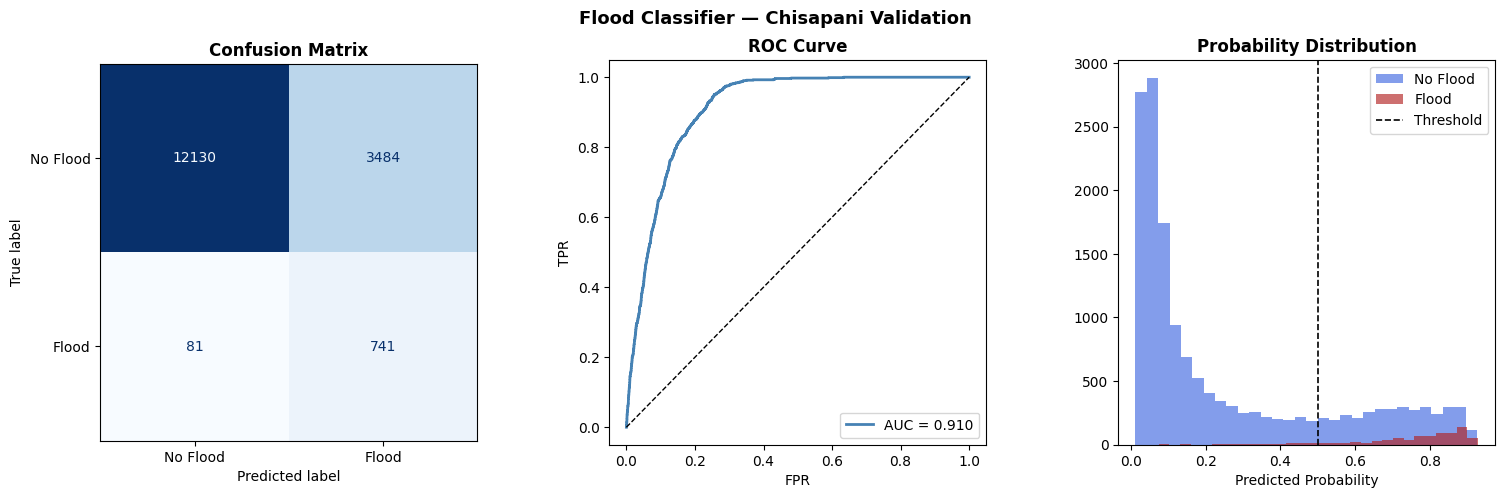


  TEST 2 — MELAMCHI → CHISAPANI WATER FLOW REGRESSOR
  ✅ PASS  WaterFlowPrediction.pth loaded.

── Sanity Checks ──
  ✅ PASS  NaN check in predictions.
  ✅ PASS  Mean bias: -12.89 cms  (under-predicting)
  ✅ PASS  Prediction range covers 91% of observed range.

── Scorecard ──
  MAE              : 848.44 cms
  RMSE             : 1107.38 cms
  R²               : 0.3750   ❌ FAIL
  MAPE             : 122.91%   ❌ FAIL
  Nash-Sutcliffe   : 0.3750   (poor)

── Peak Flow (top 5%, n=822) ──
  Peak RMSE : 3046.78 cms    ⚠️  WARN (struggles on peaks)


/tmp/ipykernel_10702/495937900.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


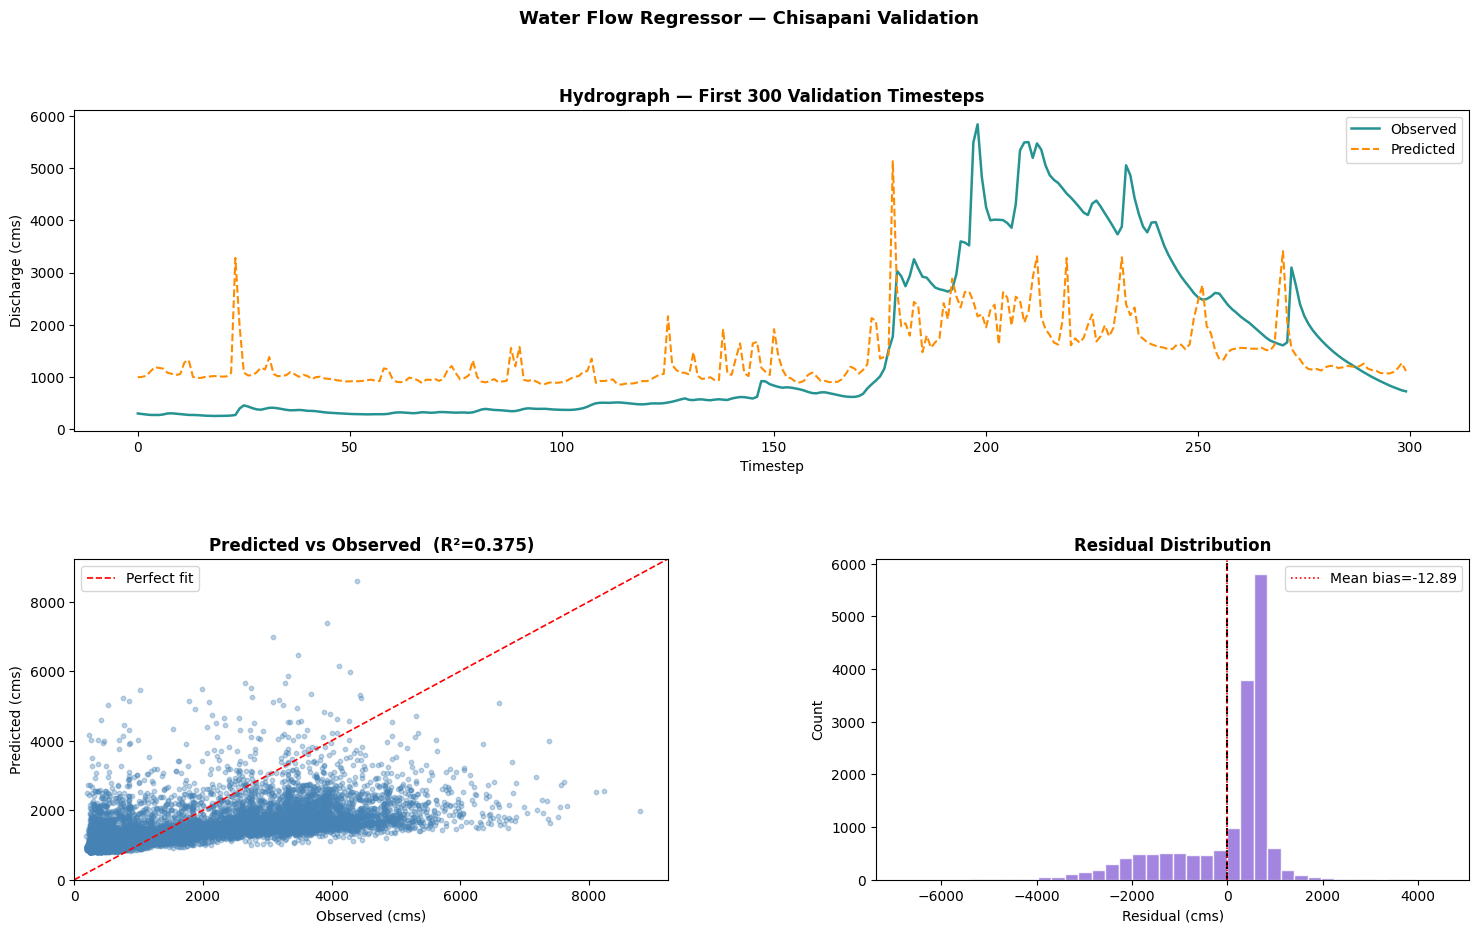


  EVALUATION COMPLETE


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, average_precision_score,
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, matthews_corrcoef
)

PASS = "✅ PASS"
FAIL = "❌ FAIL"
WARN = "⚠️  WARN"

# ─────────────────────────────────────────────────────────────
# TEST 1 — FLOOD CLASSIFICATION  (FloodPredictionModel)
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("  TEST 1 — MELAMCHI → CHISAPANI FLOOD CLASSIFIER")
print("=" * 60)

clf = FloodPredictionModel(input_size=len(feature_columns))
try:
    clf.load_state_dict(torch.load("FloodPredictionModel.pth", map_location="cpu"))
    clf.eval()
    print(f"  {PASS}  FloodPredictionModel.pth loaded.")
except FileNotFoundError:
    print(f"  {FAIL}  FloodPredictionModel.pth not found — stopping."); raise

with torch.no_grad():
    logits = clf(X_val_tensors)
    probs  = torch.sigmoid(logits).numpy().flatten()
    preds  = (probs >= 0.5).astype(int)

y_true_clf = y_val_tensors.numpy().flatten().astype(int)

# Sanity checks
print("\n── Sanity Checks ──")
if len(np.unique(preds)) < 2:
    print(f"  {FAIL}  Collapsed output — model only predicts class {np.unique(preds)[0]}.")
else:
    print(f"  {PASS}  Model predicts both classes.")

saturated_pct = np.mean((probs < 0.01) | (probs > 0.99)) * 100
print(f"  {'WARN' if saturated_pct > 20 else PASS}  Saturated outputs: {saturated_pct:.1f}%")
print(f"  INFO  Val flood rate: {y_true_clf.mean()*100:.1f}%  |  "
      f"Flood threshold (Chisapani): {flood_threshold_chisepani:.2f} m³/s")

# Metrics
print("\n── Classification Report ──")
print(classification_report(y_true_clf, preds, target_names=["No Flood", "Flood"], digits=4))

rocauc = auc(*roc_curve(y_true_clf, probs)[:2])
ap     = average_precision_score(y_true_clf, probs)
mcc    = matthews_corrcoef(y_true_clf, preds)

print("── Scorecard ──")
print(f"  Accuracy          : {accuracy_score(y_true_clf, preds)*100:.2f}%")
print(f"  F1-Score (Flood)  : {f1_score(y_true_clf, preds, zero_division=0):.4f}")
print(f"  ROC-AUC           : {rocauc:.4f}   {PASS if rocauc > 0.75 else WARN}")
print(f"  Avg Precision(AP) : {ap:.4f}   {PASS if ap > 0.50 else WARN}")
print(f"  MCC               : {mcc:.4f}   {'(strong)' if mcc>0.5 else '(moderate)' if mcc>0.2 else '(weak)'}")

# Threshold sensitivity
print("\n── Threshold Sensitivity ──")
print(f"  {'Threshold':>10}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}")
from sklearn.metrics import precision_score, recall_score
for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
    p_t = (probs >= t).astype(int)
    marker = "  ← default" if t == 0.50 else ""
    print(f"  {t:>10.2f}  "
          f"{precision_score(y_true_clf, p_t, zero_division=0):>10.4f}  "
          f"{recall_score(y_true_clf, p_t, zero_division=0):>8.4f}  "
          f"{f1_score(y_true_clf, p_t, zero_division=0):>8.4f}{marker}")

# Plots
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, wspace=0.35)

ax0 = fig.add_subplot(gs[0])
ConfusionMatrixDisplay(confusion_matrix(y_true_clf, preds),
                       display_labels=["No Flood","Flood"]).plot(
    ax=ax0, cmap="Blues", values_format="d", colorbar=False)
ax0.set_title("Confusion Matrix", fontweight="bold"); ax0.grid(False)

ax1 = fig.add_subplot(gs[1])
fpr, tpr, _ = roc_curve(y_true_clf, probs)
ax1.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {rocauc:.3f}")
ax1.plot([0,1],[0,1],"k--", lw=1); ax1.set_xlabel("FPR"); ax1.set_ylabel("TPR")
ax1.set_title("ROC Curve", fontweight="bold"); ax1.legend()

ax2 = fig.add_subplot(gs[2])
ax2.hist(probs[y_true_clf==0], bins=30, alpha=0.65, color="royalblue", label="No Flood")
ax2.hist(probs[y_true_clf==1], bins=30, alpha=0.65, color="firebrick",  label="Flood")
ax2.axvline(0.5, color="black", linestyle="--", lw=1.2, label="Threshold")
ax2.set_xlabel("Predicted Probability"); ax2.set_title("Probability Distribution", fontweight="bold")
ax2.legend()

fig.suptitle("Flood Classifier — Chisapani Validation", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# TEST 2 — WATER FLOW REGRESSION  (WaterFlowPrediction)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  TEST 2 — MELAMCHI → CHISAPANI WATER FLOW REGRESSOR")
print("=" * 60)

reg = WaterFlowPrediction(input_size=len(feature_columns))
try:
    reg.load_state_dict(torch.load("WaterFlowPrediction.pth", map_location="cpu"))
    reg.eval()
    print(f"  {PASS}  WaterFlowPrediction.pth loaded.")
except FileNotFoundError:
    print(f"  {FAIL}  WaterFlowPrediction.pth not found — stopping."); raise

with torch.no_grad():
    scaled_preds = reg(X_val_tensors_regression).numpy()

# Inverse-transform using Chisapani's own y-scaler
preds_cms = scaler_y_chisepani.inverse_transform(scaled_preds).flatten()
true_cms  = scaler_y_chisepani.inverse_transform(y_val_scaled_regression).flatten()

# Sanity checks
print("\n── Sanity Checks ──")
print(f"  {FAIL if np.any(np.isnan(preds_cms)) else PASS}  NaN check in predictions.")
bias = np.mean(preds_cms - true_cms)
print(f"  {'WARN' if abs(bias) > 0.05*np.mean(true_cms) else PASS}  "
      f"Mean bias: {bias:+.2f} cms  ({'over' if bias>0 else 'under'}-predicting)")
coverage = (preds_cms.max()-preds_cms.min()) / max(true_cms.max()-true_cms.min(), 1e-9)
print(f"  {'WARN' if coverage < 0.30 else PASS}  Prediction range covers {coverage*100:.0f}% of observed range.")

# Metrics
rmse = np.sqrt(mean_squared_error(true_cms, preds_cms))
mae  = mean_absolute_error(true_cms, preds_cms)
r2   = r2_score(true_cms, preds_cms)
mape = np.mean(np.abs((true_cms - preds_cms) / np.where(true_cms==0, 1, true_cms))) * 100
nse  = 1 - np.sum((true_cms-preds_cms)**2) / np.sum((true_cms-true_cms.mean())**2)

print("\n── Scorecard ──")
print(f"  MAE              : {mae:.2f} cms")
print(f"  RMSE             : {rmse:.2f} cms")
print(f"  R²               : {r2:.4f}   {PASS if r2>0.75 else WARN if r2>0.50 else FAIL}")
print(f"  MAPE             : {mape:.2f}%   {PASS if mape<20 else WARN if mape<40 else FAIL}")
print(f"  Nash-Sutcliffe   : {nse:.4f}   {'(excellent)' if nse>0.75 else '(satisfactory)' if nse>0.5 else '(poor)'}")

# Peak flow check (top 5%)
peak = true_cms > np.percentile(true_cms, 95)
peak_rmse = np.sqrt(mean_squared_error(true_cms[peak], preds_cms[peak]))
print(f"\n── Peak Flow (top 5%, n={peak.sum()}) ──")
print(f"  Peak RMSE : {peak_rmse:.2f} cms  "
      f"  {WARN+' (struggles on peaks)' if peak_rmse > 2*rmse else PASS+' (handles peaks well)'}")

# Plots
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.35)

ax0 = fig.add_subplot(gs[0, :])
n   = min(300, len(true_cms))
ax0.plot(true_cms[:n],  label="Observed",  color="teal",       lw=1.8, alpha=0.85)
ax0.plot(preds_cms[:n], label="Predicted", color="darkorange", lw=1.5, linestyle="--")
ax0.set_title("Hydrograph — First 300 Validation Timesteps", fontweight="bold")
ax0.set_xlabel("Timestep"); ax0.set_ylabel("Discharge (cms)"); ax0.legend()

ax1 = fig.add_subplot(gs[1, 0])
lim = max(true_cms.max(), preds_cms.max()) * 1.05
ax1.scatter(true_cms, preds_cms, alpha=0.35, s=10, color="steelblue")
ax1.plot([0,lim],[0,lim],"r--", lw=1.2, label="Perfect fit")
ax1.set_xlim(0,lim); ax1.set_ylim(0,lim)
ax1.set_xlabel("Observed (cms)"); ax1.set_ylabel("Predicted (cms)")
ax1.set_title(f"Predicted vs Observed  (R²={r2:.3f})", fontweight="bold"); ax1.legend()

ax2 = fig.add_subplot(gs[1, 1])
resid = preds_cms - true_cms
ax2.hist(resid, bins=40, color="mediumpurple", edgecolor="white", alpha=0.85)
ax2.axvline(0,    color="black", lw=1.5, linestyle="--")
ax2.axvline(bias, color="red",   lw=1.2, linestyle=":", label=f"Mean bias={bias:+.2f}")
ax2.set_xlabel("Residual (cms)"); ax2.set_ylabel("Count")
ax2.set_title("Residual Distribution", fontweight="bold"); ax2.legend()

fig.suptitle("Water Flow Regressor — Chisapani Validation", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("\n" + "=" * 60)
print("  EVALUATION COMPLETE")
print("=" * 60)

In [8]:
import os
print(os.getcwd())

/var/home/Beelzebub/Documents/Smart-Nepal-Hydro/Smart-Nepal-Hydro


In [9]:
os.listdir()

['.git',
 '.gitignore',
 'Datasets',
 'LandslideInventory_FarWesternNepal',
 'README.md',
 'chisapani_yearly_csv',
 'flood_model.pth',
 'main.ipynb',
 'requirements.txt',
 '.venv',
 'POWER_Point_Daily_19810101_20251231_028d65N_081d29E_LST.csv']

In [11]:
os.listdir("Datasets")

['melamchi_waterflow.csv', 'melamchi_weather.csv']

In [15]:
water_df = pd.read_csv("Datasets/melamchi_waterflow.csv")
weather_df = pd.read_csv("Datasets/melamchi_weather.csv")

In [13]:
print(water_df.columns)
print(weather_df.columns)

Index(['Dates', 'Values'], dtype='str')
Index(['YEAR', 'DOY', 'T2M', 'PRECTOTCORR', 'RH2M'], dtype='str')


In [14]:
water_df.head(2)
weather_df.head(2)

,YEAR,DOY,T2M,PRECTOTCORR,RH2M
0,1981,1,1.92,0.0,47.48
1,1981,2,1.83,0.0,52.88
